In [13]:
import matplotlib.pyplot as plt

import microbial_thermo as mt
from microbial_thermo.balance import infer_couples
from microbial_thermo.figures import plot_energy_explorer, plot_half_reactions, plot_redox_tower
from microbial_thermo.supplemental import supplemental_species
from microbial_thermo.library import reaction as rxn
from microbial_thermo.reaction import Couple, Reaction



In [14]:
entry = supplemental_species()["NH2OH(aq)"]
supplemental_species()

{'NH2OH(aq)': SupplementalSpecies(backend='NH2OH(aq)', formula='NH3O', delta_Gf_kJ_mol=-23.5, temperature_c=25.0, delta_Hf_kJ_mol=-98.9, display='NH_2OH', phase='aq', smiles=None, aliases=('hydroxylamine', 'NH2OH', 'NH2OH(aq)'), verified=False, provenance='Commonly cited value for aqueous hydroxylamine; NOT yet traced to a primary source. Central nitrification intermediate, absent from every pyGCC database. CHECK BEFORE USE.'),
 'Glucose(aq)': SupplementalSpecies(backend='Glucose(aq)', formula='C6H12O6', delta_Gf_kJ_mol=-917.2, temperature_c=25.0, delta_Hf_kJ_mol=None, display='glucose', phase='aq', smiles='OCC1OC(O)C(O)C(O)C1O', aliases=('glucose', 'dextrose', 'C6H12O6'), verified=False, provenance='Commonly cited value for aqueous D-glucose; sources differ by a few kJ/mol (roughly -915 to -919). NOT yet traced to a primary source. CHECK BEFORE USE.'),
 'Pyruvate(aq)': SupplementalSpecies(backend='Pyruvate(aq)', formula='C3H3O3-', delta_Gf_kJ_mol=-474.5, temperature_c=25.0, delta_Hf_k

In [50]:
from microbial_thermo.reaction import Couple, Reaction


conditions = mt.Conditions(temperature_c=25.0, pH=7)

reaction = Reaction.from_couples(
    donor=Couple.make("Fe++","Fe(OH)3", key_element="Fe"),
    acceptor=Couple.make("CO2", "Biomass"),
    conditions=conditions,
)



print(reaction.summary())

Reaction:  2 Fe++ + 11/2 H2O + 1/2 CO2(aq) -> 2 Fe(OH)3 + 4 H+ + 1/2 Biomass(aq)
  donor     Fe(OH)3/Fe++  (oxidative)  E0' = -0.138 V
  acceptor  Biomass(aq)/CO2(aq)  (reductive)  E0' = -0.403 V
  n electrons        2
  dE0'               -0.265 V
  dG0'               +51.2 kJ/mol
  dG (conditions)    +51.2 kJ/mol
  dG per electron    +25.6 kJ/mol e-


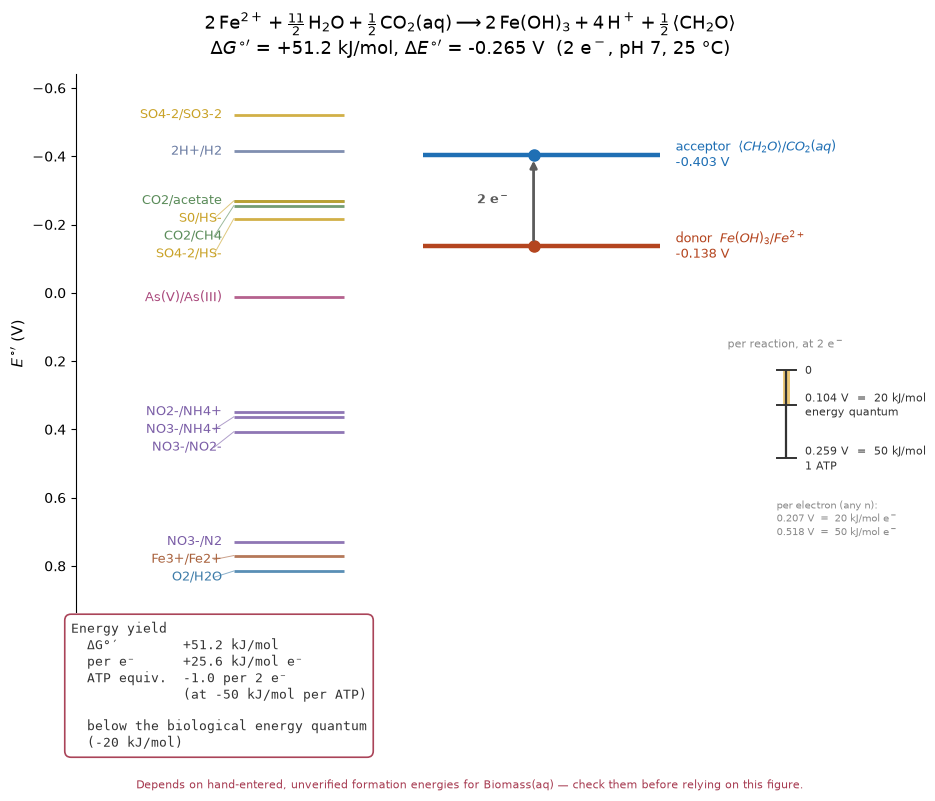

In [51]:
p = plot_redox_tower(reaction)

In [52]:
# What the acceptor couple's oxidized side holds, which the next cell indexes.
reaction.acceptor_half.couple.oxidized_side

((Species(backend='Biomass(aq)', formula='CH2O', display='\\langle CH_2O\\rangle', phase='aq', smiles=None, aliases=('biomass', 'CH2O', '<CH2O>', 'cells', 'cell carbon'), canonical=False),
  Fraction(1, 1)),)

In [53]:
reaction.acceptor_half.couple.oxidized

Species(backend='Biomass(aq)', formula='CH2O', display='\\langle CH_2O\\rangle', phase='aq', smiles=None, aliases=('biomass', 'CH2O', '<CH2O>', 'cells', 'cell carbon'), canonical=False)

In [54]:
Elist = [reaction.acceptor_half.couple..backend, 
reaction.acceptor_half.couple.oxidized_side[1][0].backend, 
reaction.acceptor_half.couple.reduced.backend, 
reaction.donor_half.couple.reduced.backend]

SyntaxError: invalid syntax (4093040316.py, line 1)

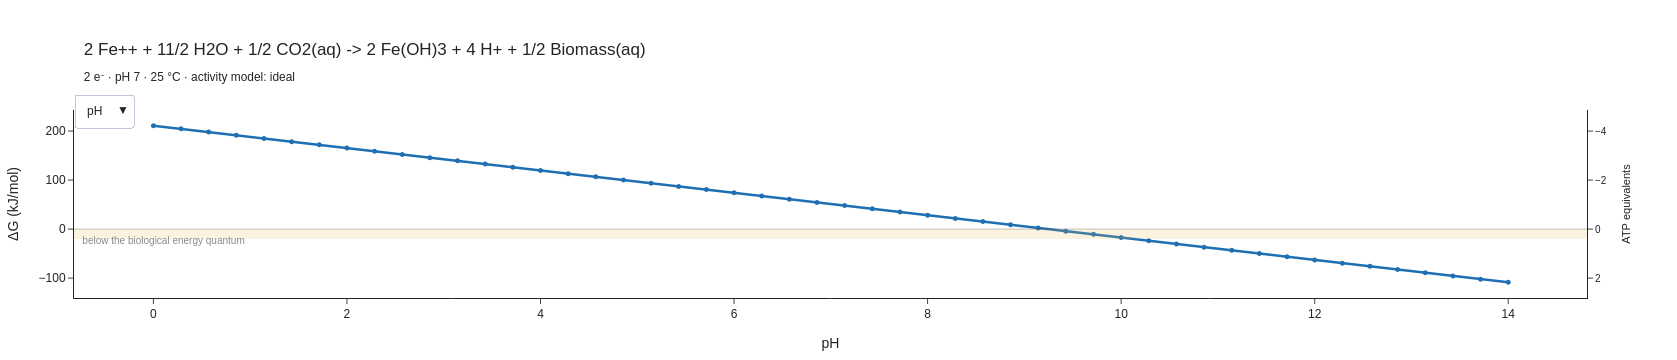

In [55]:
from microbial_thermo.sweep import concentration_axis, partial_pressure_axis, ph_axis

axes = [ph_axis(low=0, high=14.0, n=50)] #+ [concentration_axis(E) for E in Elist]
figure = plot_energy_explorer(reaction, axes=axes)

figure.show()